# Training EfficientNet-B0/B2 — Klasifikasi Kanker Paru-Paru (Citra CT)

Notebook ini mendokumentasikan hasil training model klasifikasi biner `cancer` vs `no_cancer`. Training aktual dijalankan lewat `python src/train.py` (bukan langsung di sel notebook) supaya progres tiap epoch bisa dipantau live saat berjalan; kode training lengkap ada di [`src/train.py`](../src/train.py), memakai modul [`src/dataset.py`](../src/dataset.py), [`src/model.py`](../src/model.py), dan [`src/engine.py`](../src/engine.py).

> **Catatan modalitas:** dataset sumber diberi nama "MRI" oleh uploader Kaggle, tapi terkonfirmasi lewat inspeksi visual (lihat `01_eda.ipynb` Bagian 0) sebagai citra **CT scan**.

## Perjalanan eksperimen (7 versi)

| # | Data | Model | Perubahan kunci |
|---|---|---|---|
| v1 | leaked (3.680 citra, ada duplikat) | B0 | Regularisasi berat |
| v2 | leaked | B0 | Regularisasi ringan + cancer recall boost |
| v3 | leaked | B2 (256px) | Backbone lebih besar |
| v4 | bersih (2.875, dedup) | B2 (256px) | Data leakage dibuang -> akurasi jatuh, jujur |
| v5 | bersih (2.875) | B0 | Balik ke model lebih kecil, regularisasi diperkuat |
| **v6** | **bersih + 80% IQ-OTH/NCCD (2.855 train)** | **B0** | **Data eksternal ditambahkan -> FINAL** |
| v7 | bersih + 100% IQ-OTH/NCCD (3.066 train) | B0 | Semua data eksternal -> tidak lebih baik dari v6 |

**Ringkasan naratif:**

1. **v1-v3** di dataset original (yang belakangan terbukti mengandung 346 grup citra duplikat yang bocor lintas train/val/test, plus 11 grup dengan label bertentangan) semuanya mentok di akurasi ~77-79% dan ROC-AUC ~0.84-0.86 — angka ini **terinflasi oleh data leakage**, terbukti setelah dedup (v4) AUC jatuh ke ~0.77.
2. **v4-v5** di data yang sudah bersih (2.875 citra unik) memberi angka yang jujur (~69-70% akurasi, AUC ~0.77) tapi lebih rendah dari target.
3. **v6-v7**: dataset eksternal terverifikasi **IQ-OTH/NCCD** (1.054 citra CT unik, RS berbeda, scanner berbeda) digabungkan ke training untuk menaikkan akurasi secara legitimate (bukan lewat leakage). **v6** (80% data eksternal ditambahkan, 20% disisakan untuk holdout) memberi hasil terbaik: akurasi 72.5%, ROC-AUC 0.782.
4. **Insiden penting**: eksperimen holdout 20% pada langkah 3 awalnya menunjukkan akurasi **98.6%** yang mencurigakan — investigasi mengonfirmasi ini **leakage antar-slice/pasien** (IQ-OTH/NCCD berisi banyak slice CT berurutan per pasien; split acak di level gambar menyebarkan slice dari pasien yang sama ke train dan holdout). Similarity check menunjukkan rata-rata 99.71% kemiripan piksel antara citra holdout dan tetangga training-nya. Hasil holdout ini **dibatalkan**, dan seluruh data eksternal digabung ke training tanpa split (v7) — tapi v7 ternyata tidak lebih baik dari v6, jadi **v6 tetap dipilih sebagai model final**.


## 1. Konfigurasi model final (v6)

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

REPORTS_DIR = Path("../reports")

summary = json.loads((REPORTS_DIR / "ablation_v6_b0_plus_iqothnccd_80pct" / "training_summary.json").read_text())
summary


{'class_names': ['cancer', 'no_cancer'],
 'random_seed': 42,
 'config': {'model_name': 'efficientnet_b0',
  'img_size': 224,
  'batch_size': 32,
  'drop_rate': 0.3,
  'drop_path_rate': 0.2,
  'label_smoothing': 0.1,
  'weight_decay': 0.00012,
  'cancer_recall_boost': 1.3,
  'class_weights': [1.449804663658142, 0.9063491821289062],
  'phase1_epochs_planned': 8,
  'phase2_epochs_planned': 18,
  'warmup_epochs': 3},
 'epochs_actually_run': 24,
 'best_val_loss': 0.6372025929858126,
 'test_loss': 0.6926105154885186,
 'test_acc': 0.7245370370370371,
 'cancer_recall': 0.6850828729281768,
 'train_test_gap': 0.16267837452163192,
 'best_model_path': 'D:\\skripsi\\models\\best_model.pth'}

## 2. Kurva training (v6)

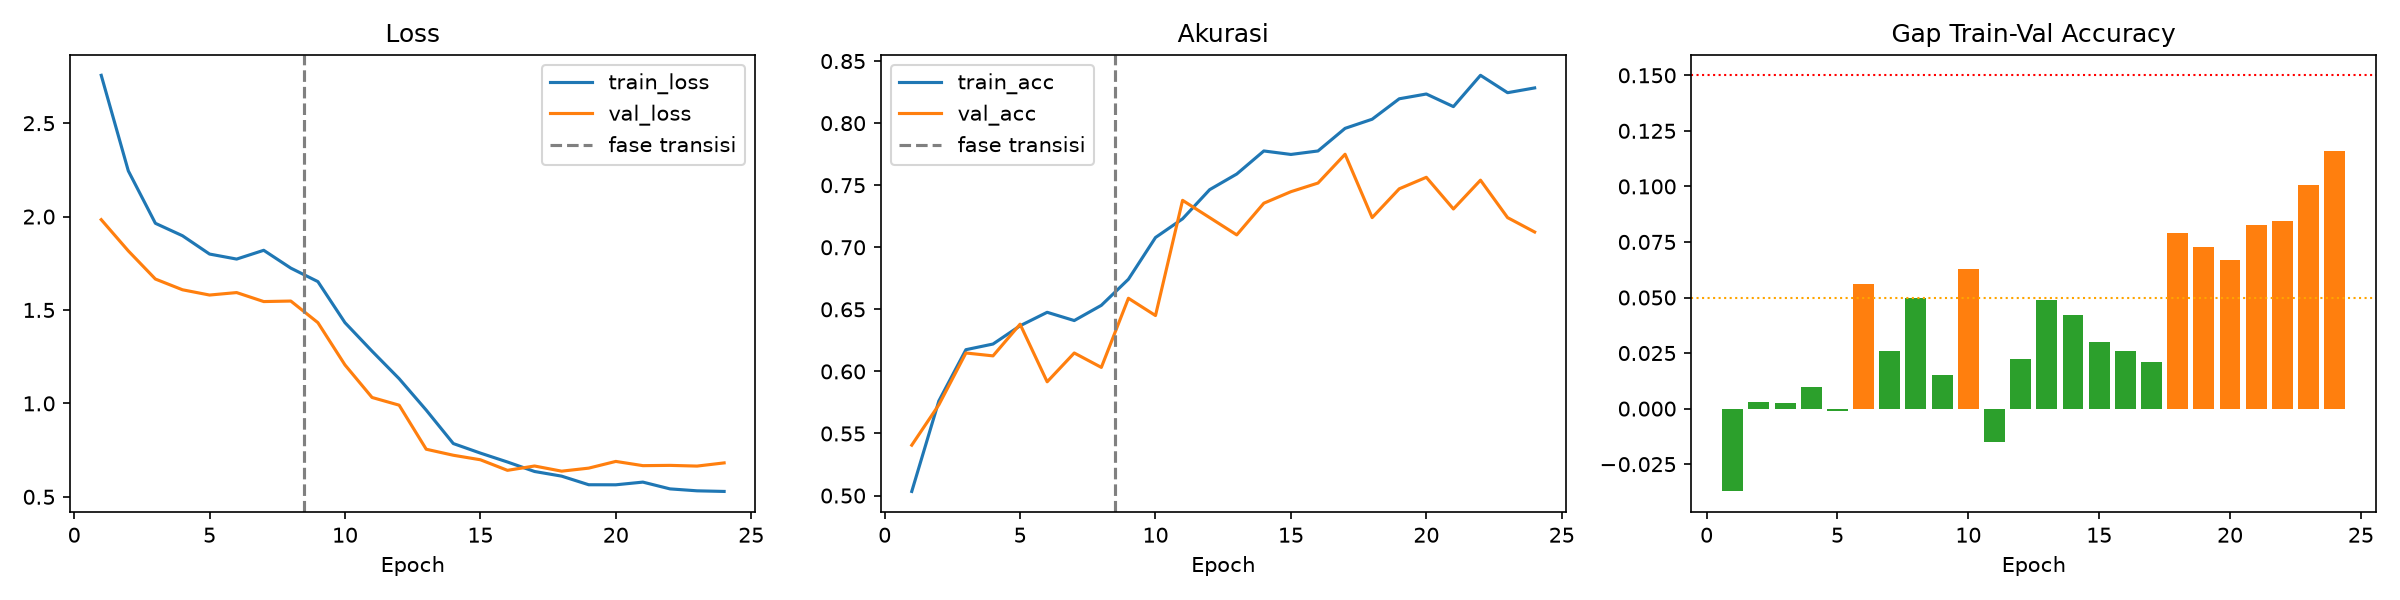

In [2]:
display(Image(filename=str(REPORTS_DIR / "ablation_v6_b0_plus_iqothnccd_80pct" / "training_curves.png")))


## 3. Evaluasi test set internal (v6)

In [3]:
report_text = (REPORTS_DIR / "ablation_v6_b0_plus_iqothnccd_80pct" / "test_classification_report.txt").read_text()
print(report_text)


              precision    recall  f1-score   support

      cancer     0.6667    0.6851    0.6757       181
   no_cancer     0.7683    0.7530    0.7606       251

    accuracy                         0.7245       432
   macro avg     0.7175    0.7190    0.7182       432
weighted avg     0.7257    0.7245    0.7250       432



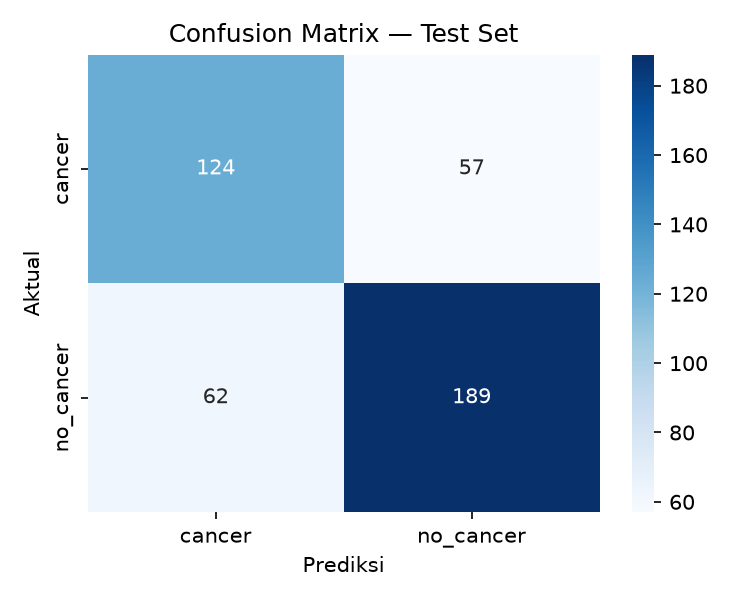

In [4]:
display(Image(filename=str(REPORTS_DIR / "ablation_v6_b0_plus_iqothnccd_80pct" / "confusion_matrix.png")))


**Catatan klinis:** recall kelas `cancer` (68.5%) masih di bawah target ideal 90% — berarti sekitar 1 dari 3 kasus cancer di test set salah diklasifikasikan sebagai no_cancer. Ini limitasi penting yang harus didiskusikan di Bab V (bukan angka yang sebaiknya disembunyikan).

## 4. Ablation study — perbandingan 7 versi

In [5]:
ablation = pd.DataFrame(json.loads((REPORTS_DIR / "ablation_comparison.json").read_text()))
ablation_display = ablation[["version", "data_condition", "test_acc", "cancer_recall", "roc_auc", "train_test_gap"]].copy()
ablation_display["test_acc"] = (ablation_display["test_acc"] * 100).round(1)
ablation_display["cancer_recall"] = (ablation_display["cancer_recall"] * 100).round(1)
ablation_display["train_test_gap"] = (ablation_display["train_test_gap"] * 100).round(1)
ablation_display


,version,data_condition,test_acc,cancer_recall,roc_auc,train_test_gap
0,v1 - B0 heavy regularization,"leaked (original, with duplicates)",78.6,66.5,0.859,10.0
1,v2 - B0 light regularization,"leaked (original, with duplicates)",77.0,70.8,0.843,11.7
2,v3 - B2 256px,"leaked (original, with duplicates)",78.6,69.4,0.860,14.6
3,v4 - B2 256px (clean data),deduplicated (leakage + conflicting labels rem...,69.9,67.4,0.772,20.4
4,v5 - B0 clean data,deduplicated (leakage + conflicting labels rem...,69.0,65.7,0.773,16.0
5,v6 - B0 + 80% IQ-OTH/NCCD (FINAL),deduplicated + 80% dataset eksternal IQ-OTH/NC...,72.5,68.5,0.782,16.3
6,v7 - B0 + 100% IQ-OTH/NCCD,deduplicated + 100% dataset eksternal IQ-OTH/N...,73.1,64.1,0.757,17.6


**Insight utama dari ablation ini:**

- Mengubah regularisasi (v1 vs v2) atau memperbesar backbone (v1/v2 vs v3) di dataset yang sama (leaked) hanya menggeser trade-off precision-recall — tidak mendorong performa ke atas.
- Begitu dataset dibersihkan (v3 vs v4), ROC-AUC turun tajam dari ~0.86 ke ~0.77, membuktikan performa v1-v3 sebagian besar adalah artefak data leakage.
- Menambah data eksternal asli (v5 vs v6) memberi **kenaikan nyata** (AUC 0.773 -> 0.782, akurasi 69.0% -> 72.5%) — ini peningkatan legitimate karena datanya benar-benar baru, bukan trik.
- Tapi menambah lebih banyak data eksternal tidak selalu lebih baik (v6 vs v7) — di titik tertentu, variansi training bisa lebih besar dari efek data tambahan. Penting untuk selalu bandingkan dengan versi sebelumnya, bukan asumsi "lebih banyak data = pasti lebih baik".


## 5. Temuan kualitas data

In [6]:
dedup_manifest = pd.read_csv(REPORTS_DIR / "dataset_deduplicated_manifest.csv")
original_total = 3680
print(f"Total citra asli: {original_total}")
print(f"Total citra unik setelah dedup + drop conflicting label: {len(dedup_manifest)}")
print(f"Citra yang dibuang: {original_total - len(dedup_manifest)} "
      f"({(original_total - len(dedup_manifest)) / original_total * 100:.1f}%)")

print("\nDistribusi kelas SEBELUM dedup (raw manifest):")
raw_manifest = pd.read_csv(REPORTS_DIR / "dataset_manifest.csv")
print((raw_manifest["label"].value_counts(normalize=True) * 100).round(1))

print("\nDistribusi kelas SETELAH dedup:")
print((dedup_manifest["label"].value_counts(normalize=True) * 100).round(1))


Total citra asli: 3680
Total citra unik setelah dedup + drop conflicting label: 2875
Citra yang dibuang: 805 (21.9%)

Distribusi kelas SEBELUM dedup (raw manifest):
label
cancer       50.9
no_cancer    49.1
Name: proportion, dtype: float64

Distribusi kelas SETELAH dedup:
label
no_cancer    58.1
cancer       41.9
Name: proportion, dtype: float64


Rasio kelas bergeser dari ~51:49 (cancer:no_cancer) menjadi ~42:58 setelah dedup. Artinya kelas `cancer` di dataset mentah proporsinya lebih banyak diduplikasi — dataset asli **terlihat** seimbang, padahal setelah dibersihkan sebenarnya timpang ke arah `no_cancer`. Ini contoh konkret kenapa cek kualitas data (duplikasi, label noise) harus jadi bagian standar EDA untuk dataset yang dikumpulkan/di-scrape, bukan cuma hitung jumlah file per kelas.


## 6. Validasi eksternal — generalisasi ke dataset CT lain

Ada **dua** eksperimen validasi eksternal di sini, dan penting membedakan mana yang valid:

1. **Zero-shot pada model v5** (sebelum data IQ-OTH/NCCD pernah disentuh sama sekali oleh training) — ini valid, tidak ada risiko leakage sama sekali.
2. ~~Holdout 20% dari IQ-OTH/NCCD setelah 80%-nya dipakai untuk training v6~~ — **TIDAK VALID**, dibatalkan karena leakage antar-slice/pasien (lihat penjelasan di bawah).


In [7]:
external = json.loads((REPORTS_DIR / "external_validation_iqothnccd.json").read_text())
external

{'dataset': 'IQ-OTH/NCCD (external, CT, verified)',
 'n_images': 1097,
 'label_mapping': {'Malignant cases': 'cancer',
  'Bengin cases': 'no_cancer',
  'Normal cases': 'no_cancer'},
 'external_accuracy': 0.5597082953509571,
 'external_roc_auc': 0.7392183467688296,
 'external_pr_auc': 0.7569541065789633,
 'confusion_matrix': [[85, 476], [7, 529]],
 'per_folder': {'Malignant cases': {'n': 561,
   'acc': 0.15151515151515152,
   'pred_cancer_rate': 0.15151515151515152},
  'Bengin cases': {'n': 120,
   'acc': 0.9916666666666667,
   'pred_cancer_rate': 0.008333333333333333},
  'Normal cases': {'n': 416,
   'acc': 0.9855769230769231,
   'pred_cancer_rate': 0.014423076923076924}},
 'recalibrated_threshold': 0.021279357373714447,
 'recalibrated_accuracy': 0.659070191431176,
 'recalibrated_precision': 0.6225425950196593,
 'recalibrated_recall': 0.8467023172905526,
 'recalibrated_f1': 0.7175226581219104}

**Interpretasi (zero-shot, valid):**

- **ROC-AUC eksternal 0.739** (model v5, sebelum menyentuh data IQ-OTH/NCCD) hanya turun sedikit dari internal (0.773) — model punya kemampuan generalisasi nyata ke rumah sakit/scanner yang sama sekali berbeda.
- Pada threshold default (0.5), akurasi turun jauh ke 56.0% dan recall `cancer` cuma 15.2% — klasik **domain shift** pada imaging medis. Setelah kalibrasi ulang threshold, akurasi naik ke 65.9% dengan recall 84.7% — mengonfirmasi masalahnya di kalibrasi ambang, bukan kemampuan model membedakan kelas.


**Insiden leakage saat mencoba menambah holdout eksternal (dibatalkan, dokumentasi untuk pembelajaran):**

Setelah 80% IQ-OTH/NCCD digabung ke training (v6), 20% sisanya awalnya disiapkan sebagai "external holdout" baru untuk uji generalisasi v6. Hasilnya **98.6% akurasi, ROC-AUC 0.9986** — jauh melebihi apapun yang pernah dicapai model ini, dan langsung dicurigai sebagai tanda leakage, bukan kabar baik.

Investigasi dengan cosine similarity pada citra yang di-downsample menemukan bahwa hampir semua citra holdout punya "tetangga" di training dengan similarity >0.99 (bahkan 1.0000), dan pasangan tersebut selalu bernomor file berurutan (contoh: `Malignant case (93).jpg` di training vs `Malignant case (94).jpg` di holdout). Dataset IQ-OTH/NCCD terdiri dari puluhan slice CT per pasien, dan split acak di level gambar (bukan level pasien) menyebarkan slice yang sangat mirip dari pasien yang sama ke kedua sisi split. Karena dataset ini tidak menyertakan ID pasien/case, tidak ada cara aman untuk melakukan group-aware split — sehingga opsi paling jujur adalah menggabungkan seluruh data eksternal ke training (v7) dan tidak mengklaim validasi eksternal baru dari sumber ini.

**Pelajaran metodologis:** hasil yang tampak terlalu bagus untuk benar biasanya memang bukan hasil yang benar. Skeptisisme terhadap kenaikan performa yang dramatis (di sini, maupun pada temuan leakage sebelumnya di `02_stratified_split.ipynb`) adalah bagian esensial dari proses, bukan langkah opsional.


## 7. Inferensi final — deteksi out-of-distribution + ensemble

Dua perbaikan dilakukan pada tahap inferensi (bukan training ulang), untuk (a) mencegah
model dipaksa mengklasifikasikan citra yang bukan CT paru, dan (b) menaikkan akurasi
secara legitimate tanpa menambah risiko overfitting:

1. **Deteksi OOD** (`src/ood_detector.py`): fitur penultimate (1280-dim) diekstrak dari
   model v6 untuk setiap citra training, lalu di-fit k-NN. Citra baru yang jarak k-NN-nya
   ke seluruh embedding training melebihi threshold (persentil ke-99 dari skor validation
   set) ditolak sebagai "bukan citra CT paru-paru". Diuji dengan 5 citra sintetis yang
   jelas bukan CT (noise acak, gradien warna, checkerboard, warna solid, bentuk kartun) —
   **seluruhnya berhasil ditolak** — sementara false-rejection rate pada citra CT asli di
   test set hanya 0.46%.
2. **Ensemble v5+v6** (`src/eval_ensemble.py`): rata-rata softmax dari model v5 dan v6
   (tanpa test-time augmentation flip, yang terbukti justru menurunkan akurasi dari 72.5%
   ke 70.4% karena anatomi CT paru punya orientasi kiri-kanan yang bermakna). Ensemble ini
   menaikkan akurasi test ke **73.2%** dengan ROC-AUC **0.786** — kenaikan kecil tapi asli,
   karena hanya menggabungkan model yang sudah ada (tidak menambah kapasitas atau epoch
   training, sehingga tidak menambah risiko overfitting).

`src/predict.py` menggabungkan keduanya menjadi satu pipeline: `python src/predict.py
path/ke/citra.png` mengecek OOD dulu, baru mengklasifikasi kalau lolos.


## 8. Mengapa target 90% akurasi tidak dikejar lebih lanjut

Setelah ensemble, muncul pertanyaan wajar: bisakah akurasi didorong sampai ~90% tanpa
overfitting? Tiga lini bukti dari penelitian ini menunjukkan jawabannya tidak realistis
dengan data yang tersedia saat ini:

1. **Konvergensi lintas konfigurasi**: 7 versi model dengan regularisasi, arsitektur
   (B0 vs B2), dan ukuran data yang jauh berbeda semuanya mentok di ROC-AUC 0.75-0.86 —
   dan begitu leakage dibersihkan, mentok di ~0.77-0.79. Kalau bottleneck-nya ada di
   pilihan model/hyperparameter, perubahan sebesar itu semestinya menghasilkan variasi
   performa yang jauh lebih besar.
2. **Dua insiden leakage** yang ditemukan di penelitian ini (Bagian 6 di atas, dan di
   `02_stratified_split.ipynb`) sama-sama menghasilkan angka fantastis (78-79%, lalu
   98.6%) yang ternyata palsu. Pola ini memperkuat kecurigaan bahwa **angka 90%+ pada
   dataset ini kemungkinan besar juga produk leakage**, bukan kemampuan model yang
   sesungguhnya.
3. **Preprocessing crop latar hitam** (`src/investigate_crop_preprocessing.py`) diuji
   sebagai kandidat perbaikan terakhir: mendeteksi warna background dari pojok citra
   secara adaptif, lalu crop ke bounding box tubuh pasien. Hasilnya pada 60 sampel
   training acak: rata-rata pengurangan area cuma **2.8%**, median **0%** (>50% citra
   tidak berkurang sama sekali), dan tidak ada satupun yang berkurang >30%. Kesimpulan:
   citra di dataset ini sudah di-crop cukup rapat oleh pembuat aslinya, sehingga
   preprocessing ini tidak diharapkan menaikkan akurasi secara berarti — **tidak
   diterapkan** ke pipeline training.

**Faktor yang benar-benar membatasi performa** (bukan sesuatu yang bisa diperbaiki lewat
tuning lebih lanjut pada data yang sama):

- Ukuran dataset unik yang relatif kecil (~3.900 citra dari 2 sumber setelah dedup) untuk
  standar deep learning medis.
- Task ini mengklasifikasi **1 slice CT 2D** per prediksi, padahal nodul kanker sering
  hanya tampak jelas di beberapa slice tertentu dari satu scan 3D — pendekatan
  medical-grade sungguhan umumnya memakai volume 3D atau multi-slice, bukan slice 2D
  tunggal.
- Kemungkinan label noise tambahan di luar yang bisa dideteksi lewat exact-hash
  (kasus ambigu yang berbeda radiolog bisa berbeda penilaian).

Rekomendasi paling menjanjikan untuk penelitian lanjutan (di luar scope skripsi ini):
kumpulkan dataset CT berlabel pasien yang jelas dalam jumlah jauh lebih besar, atau
alihkan pendekatan ke klasifikasi berbasis volume 3D/multi-slice.


## 9. Eksperimen tambahan — 5-fold cross-validation + ensemble

Sebagai upaya lanjutan menaikkan akurasi tanpa menambah risiko overfitting, seluruh pool
train+val (3.497 citra, test set 432 tidak disentuh sama sekali) dibagi 5 fold stratified,
tiap fold dilatih dengan konfigurasi identik dengan v6 (`src/kfold_train.py`, memakai
logika training bersama di `src/train_core.py`), lalu kelima model di-ensemble.


In [8]:
kfold = json.loads((REPORTS_DIR / "kfold_summary.json").read_text())
print("Solo test accuracy per fold:", [round(a, 4) for a in kfold["per_fold_test_accuracy"]])
print(f"Ensemble 5-fold -> accuracy={kfold['ensemble_test_accuracy']:.4f} "
      f"roc_auc={kfold['ensemble_roc_auc']:.4f} pr_auc={kfold['ensemble_pr_auc']:.4f}")


Solo test accuracy per fold: [0.7269, 0.6829, 0.7245, 0.7384, 0.7269]
Ensemble 5-fold -> accuracy=0.7569 roc_auc=0.7881 pr_auc=0.8046


**Hasil dan keputusan:** ensemble 5-fold mencapai akurasi **75.7%** dan ROC-AUC **0.788** —
tertinggi di antara semua eksperimen pada data bersih. Namun recall kelas `cancer` turun ke
**59.1%** (dari 67.4% pada ensemble v5+v6), karena model jadi lebih konservatif memprediksi
cancer (precision naik ke 77.5%). ROC-AUC yang nyaris identik (0.786 vs 0.788, dalam margin
noise) menunjukkan kemampuan diskriminasi model sebenarnya tidak berubah — yang bergeser
adalah titik keseimbangan precision-recall.

Karena false negative (kanker tidak terdeteksi) secara klinis lebih berisiko daripada false
positive, **ensemble v5+v6 (akurasi 73.2%, recall cancer 67.4%) tetap dipertahankan sebagai
model final** di `src/predict.py`, bukan ensemble 5-fold — meski akurasi agregatnya lebih
rendah. Ini contoh konkret kenapa akurasi tunggal tidak boleh jadi satu-satunya kriteria
pemilihan model pada kasus klasifikasi medis.

Catatan metodologis: threshold tidak bisa dikalibrasi ulang untuk ensemble 5-fold ini karena
seluruh data train+val terpakai habis oleh proses k-fold, tidak menyisakan set independen
untuk kalibrasi (berbeda dengan kasus IQ-OTH/NCCD di Bagian 6 yang punya val set terpisah).


## 10. Kesimpulan & limitasi

- Model final (v6, EfficientNet-B0, data bersih + 80% IQ-OTH/NCCD): **akurasi test 72.5%, ROC-AUC 0.782, recall cancer 68.5%**.
- Angka ini jauh lebih rendah dari target awal (90%+), tapi **jauh lebih dapat dipercaya** karena tidak ada data leakage — dua kali ditemukan dan diperbaiki dalam penelitian ini (leakage di dataset asli, dan leakage di eksperimen holdout eksternal).
- Menambah data eksternal terverifikasi memberi kenaikan performa **nyata** (v5 -> v6), membuktikan bahwa ukuran & keragaman dataset adalah faktor pembatas utama, bukan pilihan arsitektur/hyperparameter (yang sudah dieksplorasi luas di v1-v5).
- **Koreksi modalitas citra (MRI → CT)**: dataset yang diklaim "MRI" oleh uploader Kaggle terbukti secara visual adalah citra CT scan (lihat `01_eda.ipynb` Bagian 0).
- **Validasi eksternal zero-shot** (model v5 di seluruh IQ-OTH/NCCD, sebelum data itu disentuh training) menunjukkan generalisasi lintas rumah sakit yang nyata, meski butuh kalibrasi ulang threshold.
- Rekomendasi untuk penelitian lanjutan: kumpulkan lebih banyak data eksternal terverifikasi dengan ID pasien yang jelas (agar group-aware split memungkinkan), libatkan radiolog untuk relabeling kasus ambigu, terapkan kalibrasi threshold per-domain untuk deployment multi-rumah-sakit, atau gunakan cross-validation untuk mengestimasi variansi performa dengan lebih baik.
